In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
res = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Abla1.csv')
res['source_target_ratio'] = res['source_size'] / res['target_size']
# res.groupby(['Method', 'source_target_ratio']).mean().reset_index().to_csv('sim_abla.csv', index=False)
res = res[(res["Metric"] != 'AvgPinball') & (res["Metric"] != 'CRPS')]
res.groupby(['Method', 'Metric', 'source_target_ratio']).mean().reset_index().to_csv('sim_abla_new.csv', index=False)

a = res.groupby(['Method', 'Metric', 'source_target_ratio']).mean().reset_index()
a

,Method,Metric,source_target_ratio,Value,source_size,target_size
0,Engression_Only,KRR,1.0,0.783197,100.0,100.0
1,Engression_Only,KRR,2.0,0.975713,200.0,100.0
2,Engression_Only,KRR,5.0,1.368569,500.0,100.0
3,Engression_Only,KRR,10.0,1.815128,1000.0,100.0
4,Engression_Only,KRR,15.0,2.154469,1500.0,100.0
...,...,...,...,...,...,...
107,TLCQM,XGBoost,5.0,0.313986,500.0,100.0
108,TLCQM,XGBoost,10.0,0.317147,1000.0,100.0
109,TLCQM,XGBoost,15.0,0.321031,1500.0,100.0
110,TLCQM,XGBoost,20.0,0.323390,2000.0,100.0


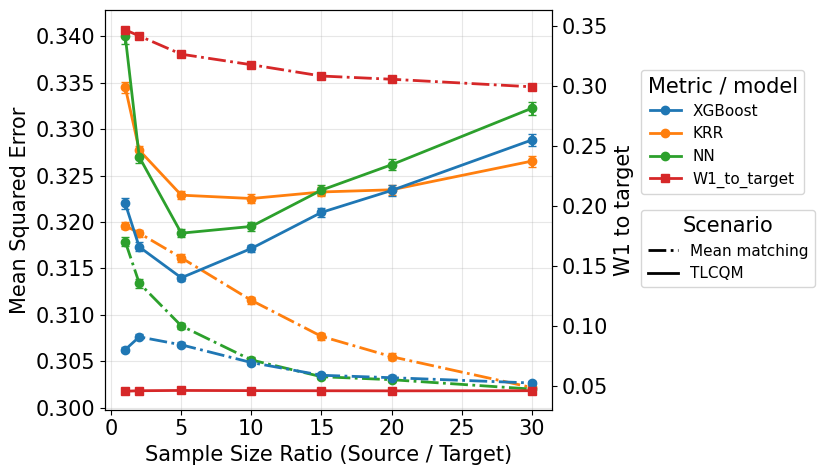

In [16]:
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 15})

summary = (
    res
    .groupby(["Method", "Metric", "source_target_ratio"])
    .agg(
        mean_value=("Value", "mean"),
        se_value=("Value", lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)

# ---- rename columns to match plotting logic ----
summary = summary.rename(columns={
    "Method": "Scenario",
    "Metric": "MetricName"
})

# ---- prettier scenario names ----
scenario_name_map = {
    "Engression_Only": "Engression only",
    "Mean_Matching": "Mean matching",
    "OT_Calibration": "OT calibration",
    "TLCQM": "TLCQM"
}
summary["Scenario"] = summary["Scenario"].replace(scenario_name_map)

# ---- keep only scenarios you want ----
summary = summary[summary["Scenario"].isin(["Mean matching", "TLCQM"])].copy()

# ---- split metrics ----
mse_metrics = ["XGBoost", "KRR", "NN"]
w1_metric = "W1_to_target"

summary_mse = summary[summary["MetricName"].isin(mse_metrics)].copy()
summary_w1 = summary[summary["MetricName"] == w1_metric].copy()

# ---- color & linestyle maps ----
color_map = {
    "XGBoost": "tab:blue",
    "KRR": "tab:orange",
    "NN": "tab:green",
    "W1_to_target": "tab:red"
}

linestyle_map = {
    "Mean matching": "-.",
    "TLCQM": "-"
}

marker_map = {
    "XGBoost": "o",
    "KRR": "o",
    "NN": "o",
    "W1_to_target": "s"
}

# ---- plot with twin y-axis ----
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

# ---- MSE curves on left axis ----
for (metric, scenario), sub in summary_mse.groupby(["MetricName", "Scenario"]):
    sub = sub.sort_values("source_target_ratio")
    ax1.errorbar(
        sub["source_target_ratio"],
        sub["mean_value"],
        yerr=sub["se_value"],
        color=color_map[metric],
        linestyle=linestyle_map[scenario],
        marker=marker_map[metric],
        linewidth=2,
        capsize=3
    )

# ---- W1 curves on right axis ----
for scenario, sub in summary_w1.groupby("Scenario"):
    sub = sub.sort_values("source_target_ratio")
    ax2.errorbar(
        sub["source_target_ratio"],
        sub["mean_value"],
        yerr=sub["se_value"],
        color=color_map["W1_to_target"],
        linestyle=linestyle_map[scenario],
        marker=marker_map["W1_to_target"],
        linewidth=2,
        capsize=3
    )

# ---- legends ----
metric_handles = [
    Line2D([0], [0], color=color_map[m], lw=2, marker=marker_map[m], label=m)
    for m in ["XGBoost", "KRR", "NN", "W1_to_target"]
]

scenario_handles = [
    Line2D([0], [0], color="black", lw=2,
           linestyle=linestyle_map[s], label=s)
    for s in ["Mean matching", "TLCQM"]
]

legend_metric = ax1.legend(
    handles=metric_handles,
    title="Metric / model",
    loc="upper left",
    bbox_to_anchor=(1.2, 0.85),
    borderaxespad=0.0,
    fontsize=11
)

legend_scenario = ax1.legend(
    handles=scenario_handles,
    title="Scenario",
    loc="upper left",
    bbox_to_anchor=(1.2, 0.50),
    borderaxespad=0.0,
    fontsize=11
)

ax1.add_artist(legend_metric)

# ---- labels & formatting ----
ax1.set_xlabel("Sample Size Ratio (Source / Target)")
ax1.set_ylabel("Mean Squared Error")
ax2.set_ylabel("W1 to target")

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
summary

,Method,source_target_ratio,mean_mse,se_mse,Model,Scenario
1,KRR_Mean_Matching,30.0,0.172602,0.000266,KRR,Mean matching
3,KRR_TLCQM,30.0,0.182024,0.000394,KRR,TLCQM
5,NN_Mean_Matching,30.0,0.179645,0.000256,NN,Mean matching
7,NN_TLCQM,30.0,0.191660,0.000498,NN,TLCQM
9,XGBoost_Mean_Matching,30.0,0.181625,0.000282,XGBoost,Mean matching
11,XGBoost_TLCQM,30.0,0.191871,0.000510,XGBoost,TLCQM
